# 04 — Baseline Backtest: IC Analysis + Quintile Portfolios

Three required experiments from the handout, all run on SP500, SP1500, and RU3K:

1. **Single-feature IC analysis** — Spearman IC of `ATCClassifierScore` and each `EventsScore_*` variant vs forward returns at horizons 1, 3, 5, 10, 20 days. Report by year and by sector.
2. **Quintile / decile portfolios** — sort events by signal at T-0, hold for chosen horizon, report long-only, short-only, and long-short cumulative returns + Sharpe.
3. **Placebo test** — run the same quintile backtest on the Fluff/Filler-only signal. This should produce ≈0 alpha; material Sharpe here means a look-ahead bug.

**This is the sanity-check notebook.** If the ATCClassifierScore baseline doesn't show clean quintile spread here, do not proceed to ML modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT      = Path(os.getenv("ATC_PROJECT_ROOT",
                              Path.cwd().parent if Path.cwd().name == 'notebooks'
                              else Path.cwd())).resolve()
DATA_DIR     = PROJECT / 'data'
FEATURES_PQ  = DATA_DIR / 'features.parquet'
PLACEBO_PQ   = DATA_DIR / 'placebo_features.parquet'
FIG_DIR      = PROJECT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

HORIZONS    = [1, 3, 5, 10, 20]
TARGET_COLS = [f'fwd_{h}d' for h in HORIZONS]
UNIVERSES   = ['in_sp500', 'in_sp1500', 'in_ru3k']
UNIV_LABELS = {'in_sp500': 'SP500', 'in_sp1500': 'SP1500', 'in_ru3k': 'RU3K proxy'}

feat_df    = pd.read_parquet(FEATURES_PQ)
placebo_df = pd.read_parquet(PLACEBO_PQ)
print(f'Feature matrix: {feat_df.shape}')


Feature matrix: (376790, 92)


## 4.1 Spearman IC — ATCClassifierScore vs Forward Returns

Information Coefficient (IC) = Spearman rank correlation between the signal score and the subsequent return. 
- IC > 0 means the signal positively predicts returns on that horizon
- We report **annual IC** (by year) to detect regime changes
- **IC-t-stat** = IC / std(IC) * sqrt(N) — the key significance metric
- We also report **ICIR** (IC information ratio) = mean(IC) / std(IC)

In [2]:
def spearman_ic(signal: pd.Series, returns: pd.Series) -> float:
    mask = signal.notna() & returns.notna()
    if mask.sum() < 30:
        return np.nan
    return stats.spearmanr(signal[mask], returns[mask])[0]


def ic_table(df, signal_col, univ_col, horizons=HORIZONS):
    """Compute annual IC for each horizon. Returns a DataFrame."""
    sub = df[df[univ_col]].copy()
    sub['Year'] = pd.to_datetime(sub['entry_date']).dt.year
    rows = []
    for year, grp in sub.groupby('Year'):
        row = {'Year': year}
        for h in horizons:
            row[f'IC_{h}d'] = spearman_ic(grp[signal_col], grp[f'fwd_{h}d'])
        rows.append(row)
    ic_df = pd.DataFrame(rows).set_index('Year')
    # Summary row
    summary = pd.Series(
        {f'IC_{h}d': ic_df[f'IC_{h}d'].mean() for h in horizons},
        name='MEAN'
    )
    icir_row = pd.Series(
        {f'IC_{h}d': ic_df[f'IC_{h}d'].mean() / (ic_df[f'IC_{h}d'].std() + 1e-8)
         for h in horizons},
        name='ICIR'
    )
    return pd.concat([ic_df, summary.to_frame().T, icir_row.to_frame().T])


print('=== IC Table: ATCClassifierScore — SP500 ===')
ic_sp500 = ic_table(feat_df, 'ATCClassifierScore', 'in_sp500')
print(ic_sp500.round(4).to_string())

=== IC Table: ATCClassifierScore — SP500 ===
       IC_1d   IC_3d   IC_5d  IC_10d  IC_20d
2010  0.0136 -0.0867 -0.0815 -0.0566 -0.0816
2011  0.0218 -0.0460  0.0049 -0.0085  0.0505
2012  0.0670  0.0940  0.1143  0.1395  0.1201
2013 -0.0126 -0.0010  0.0659  0.0322  0.0991
2014  0.0510  0.1119  0.0893  0.0816  0.1023
2015  0.0275  0.0216  0.0482  0.0721  0.0802
2016  0.0177  0.0877  0.0306  0.0353  0.1210
2017  0.0239  0.1096  0.0983  0.0694  0.1147
2018  0.0466 -0.0221 -0.0765  0.0156  0.0346
2019  0.0335  0.0954  0.0515  0.1078  0.1233
2020  0.0767  0.0836  0.0525  0.0790 -0.0678
2021  0.0208 -0.0441 -0.0372 -0.0198  0.0114
2022  0.0258  0.0332  0.0104  0.0137  0.0517
2023  0.0415  0.0217  0.0191 -0.0374  0.0275
2024  0.0176  0.0251 -0.0211  0.0211  0.0189
2025  0.0363  0.0420 -0.0029 -0.0051 -0.0143
2026 -0.0011  0.0194 -0.0578 -0.0262 -0.0429
MEAN  0.0299  0.0321  0.0181  0.0302  0.0440
ICIR  1.3343  0.5395  0.3054  0.5548  0.6561


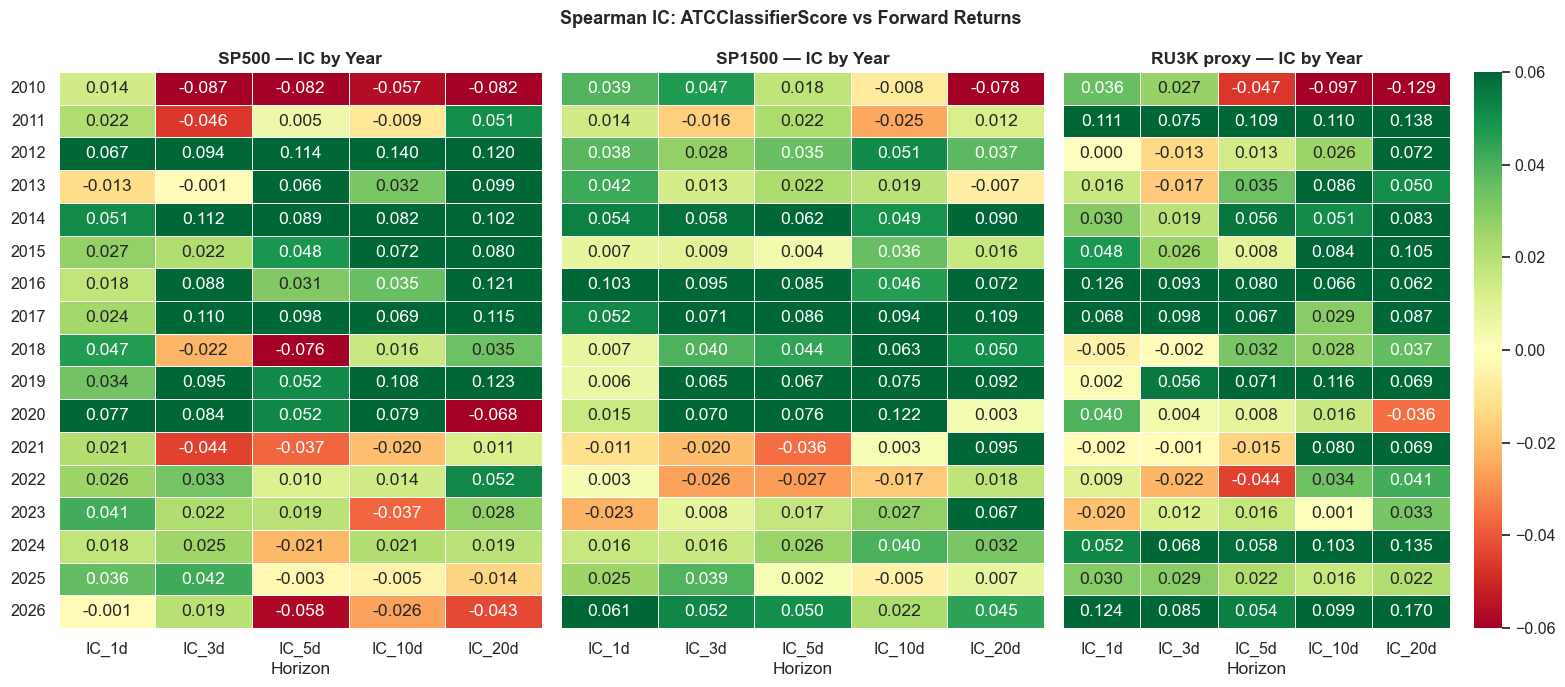

In [3]:
# IC heatmap across all universes and horizons
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

for ax, univ in zip(axes, UNIVERSES):
    ic_df = ic_table(feat_df, 'ATCClassifierScore', univ)
    # Drop summary rows for heatmap
    heatmap_data = ic_df.drop(index=['MEAN','ICIR'], errors='ignore').astype(float)
    sns.heatmap(
        heatmap_data,
        ax=ax, cmap='RdYlGn', center=0, vmin=-0.06, vmax=0.06,
        annot=True, fmt='.3f', linewidths=0.5, cbar=(ax == axes[-1])
    )
    ax.set_title(f'{UNIV_LABELS[univ]} — IC by Year', fontweight='bold')
    ax.set_xlabel('Horizon')
    ax.set_ylabel('')

fig.suptitle('Spearman IC: ATCClassifierScore vs Forward Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_heatmap_atc.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 IC by Sector

Does the signal work uniformly across GICS sectors, or is it driven by a specific sector?  
Concentrated sector alpha is a risk — it may reflect sector-level beta, not stock-specific NLP signal.

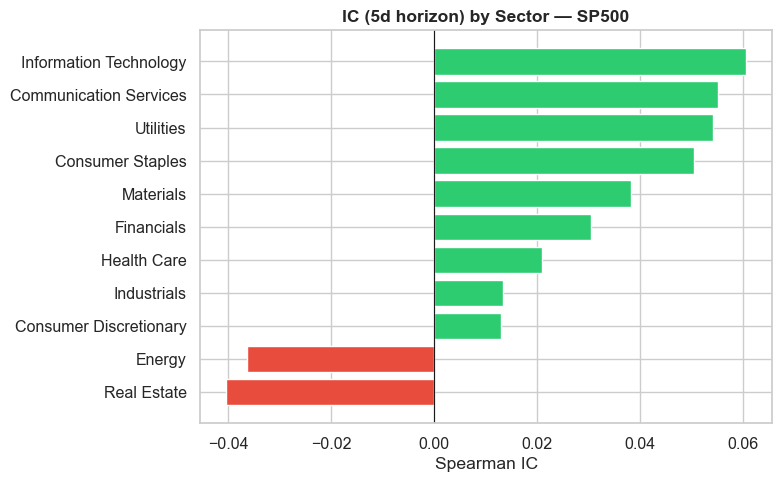

                         IC_5d     N
SECTOR                              
Real Estate            -0.0405  1259
Energy                 -0.0363  1541
Consumer Discretionary  0.0130  2632
Industrials             0.0133  3786
Health Care             0.0209  2538
Financials              0.0304  4244
Materials               0.0383  1941
Consumer Staples        0.0505  1092
Utilities               0.0541   663
Communication Services  0.0551  1293
Information Technology  0.0606  3052


In [4]:
def ic_by_sector(df, signal_col, univ_col, horizon=5):
    sub = df[df[univ_col]].copy()
    rows = []
    for sector, grp in sub.groupby('SECTOR'):
        ic = spearman_ic(grp[signal_col], grp[f'fwd_{horizon}d'])
        rows.append({'SECTOR': sector, f'IC_{horizon}d': ic, 'N': len(grp)})
    return pd.DataFrame(rows).set_index('SECTOR').sort_values(f'IC_{horizon}d')

ic_sec = ic_by_sector(feat_df, 'ATCClassifierScore', 'in_sp500', horizon=5)

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in ic_sec['IC_5d'].values]
ax.barh(ic_sec.index, ic_sec['IC_5d'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('IC (5d horizon) by Sector — SP500', fontweight='bold')
ax.set_xlabel('Spearman IC')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print(ic_sec.round(4).to_string())

## 4.3 Quintile Portfolio Construction

On each trade date, rank all events in the universe by signal score into 5 quintiles (Q1=lowest, Q5=highest). Hold each quintile for the chosen horizon. Compute:
- **Long-only** (Q5), **short-only** (Q1), **long-short** (Q5 − Q1) cumulative returns
- **Annualised Sharpe** = mean(period_return) / std(period_return) * sqrt(252 / horizon)

We use a **daily rebalance** here (each event trades independently on its entry date).  
Portfolio-level weekly rebalancing is in notebook 06.

In [5]:
def quintile_backtest(df, signal_col, univ_col, horizon=5, n_quantiles=5, tc_bps=5):
    """
    Event-driven quintile backtest.
    Each event is assigned to a quintile on its entry date.
    Returns DataFrame of (period, quintile, avg_return) and summary stats.
    """
    tc_cost = tc_bps / 10000  # one-way
    sub     = df[df[univ_col]].copy()
    ret_col = f'fwd_{horizon}d'
    sub     = sub.dropna(subset=[signal_col, ret_col])

    # Assign quintile cross-sectionally on each entry_date.
    # Guard: skip dates with fewer than n_quantiles events (can't form distinct bins).
    def safe_qcut(s):
        if len(s) < n_quantiles:
            return pd.Series(np.nan, index=s.index)
        try:
            return pd.qcut(s.rank(method='first'), n_quantiles,
                           labels=range(1, n_quantiles + 1), duplicates='drop')
        except ValueError:
            return pd.Series(np.nan, index=s.index)

    sub['quintile'] = sub.groupby('entry_date')[signal_col].transform(safe_qcut)
    sub = sub.dropna(subset=['quintile'])
    sub['quintile'] = sub['quintile'].astype(int)

    # Average return per (period, quintile)
    sub['period'] = sub['entry_date'].dt.to_period('W')
    rets = sub.groupby(['period', 'quintile'])[ret_col].mean().unstack('quintile')
    rets.columns = [f'Q{i}' for i in rets.columns]

    # Long-short = Q_top - Q_bottom (net of 2-way transaction costs)
    top_col = f'Q{n_quantiles}'
    if top_col not in rets.columns or 'Q1' not in rets.columns:
        raise ValueError(f'Not enough quantile columns: {rets.columns.tolist()}')
    rets['LS'] = rets[top_col] - rets['Q1'] - 2 * tc_cost

    # Cumulative returns
    cum = (1 + rets).cumprod() - 1

    # Annualised Sharpe
    periods_per_year = 252 / horizon
    sharpes = {}
    for col in rets.columns:
        r = rets[col].dropna()
        sharpes[col] = r.mean() / (r.std() + 1e-9) * np.sqrt(periods_per_year)

    return rets, cum, sharpes


# Run for SP500, 5-day horizon
rets_sp500, cum_sp500, sh_sp500 = quintile_backtest(
    feat_df, 'ATCClassifierScore', 'in_sp500', horizon=5
)

print('Annualised Sharpe by quintile (SP500, 5d horizon, 5bps tc):')
for k, v in sh_sp500.items():
    print(f'  {k}: {v:.3f}')


Annualised Sharpe by quintile (SP500, 5d horizon, 5bps tc):
  Q1: 0.659
  Q2: 0.310
  Q3: 0.372
  Q4: 0.083
  Q5: 0.539
  LS: -0.292


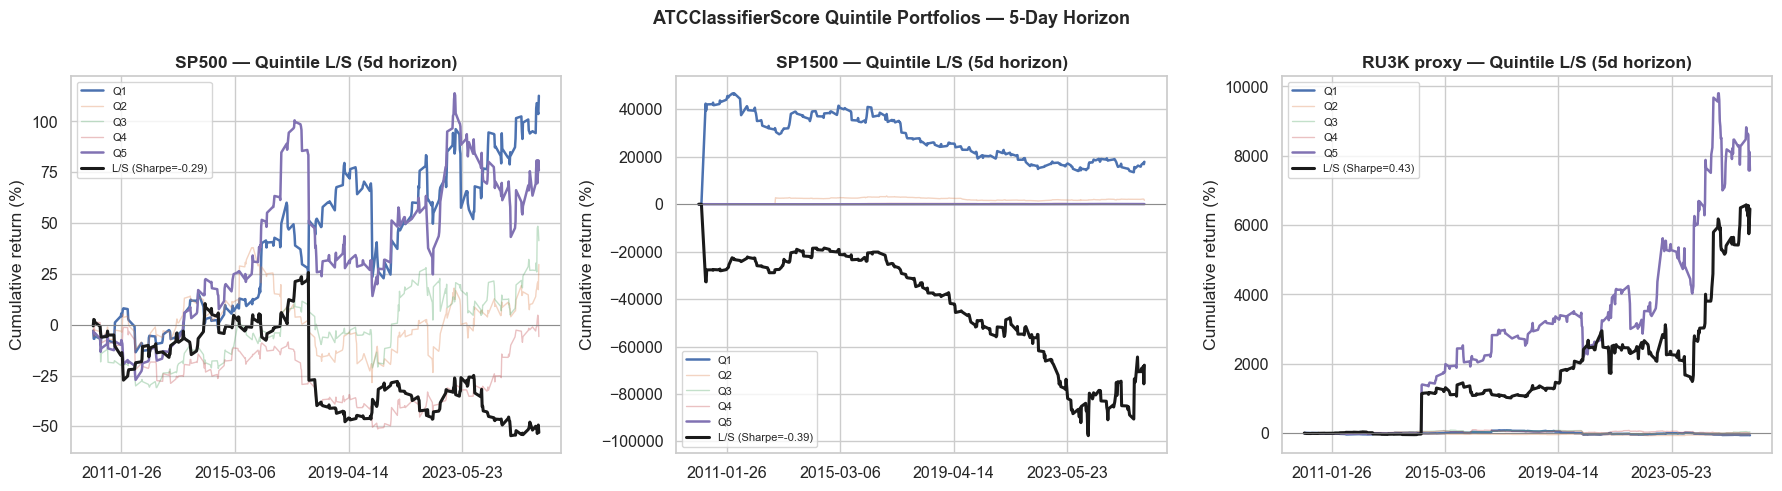

In [6]:
# Quintile spread chart — run all 3 universes × all horizons, show 5d results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, univ in zip(axes, UNIVERSES):
    _, cum, sharpes = quintile_backtest(feat_df, 'ATCClassifierScore', univ, horizon=5)
    label  = UNIV_LABELS[univ]
    ls_sh  = sharpes.get('LS', np.nan)

    for col in [c for c in cum.columns if c.startswith('Q')]:
        alpha = 0.35
        lw    = 1.0
        if col == f'Q{5}':
            alpha, lw = 1.0, 1.8
        elif col == 'Q1':
            alpha, lw = 1.0, 1.8
        ax.plot(cum.index.to_timestamp(), cum[col] * 100, alpha=alpha, lw=lw, label=col)

    ax.plot(cum.index.to_timestamp(), cum['LS'] * 100, 'k-', lw=2.2, label=f'L/S (Sharpe={ls_sh:.2f})')
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{label} — Quintile L/S (5d horizon)', fontweight='bold')
    ax.set_ylabel('Cumulative return (%)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

fig.suptitle('ATCClassifierScore Quintile Portfolios — 5-Day Horizon', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'quintile_ls_5d.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Decile Spread + Drawdown Analysis

We also run a **decile** (10-bucket) version. The long-short spread between decile 10 and decile 1 is typically wider than quintile spread — important for understanding signal convexity. We also plot the **rolling drawdown** of the L/S strategy.

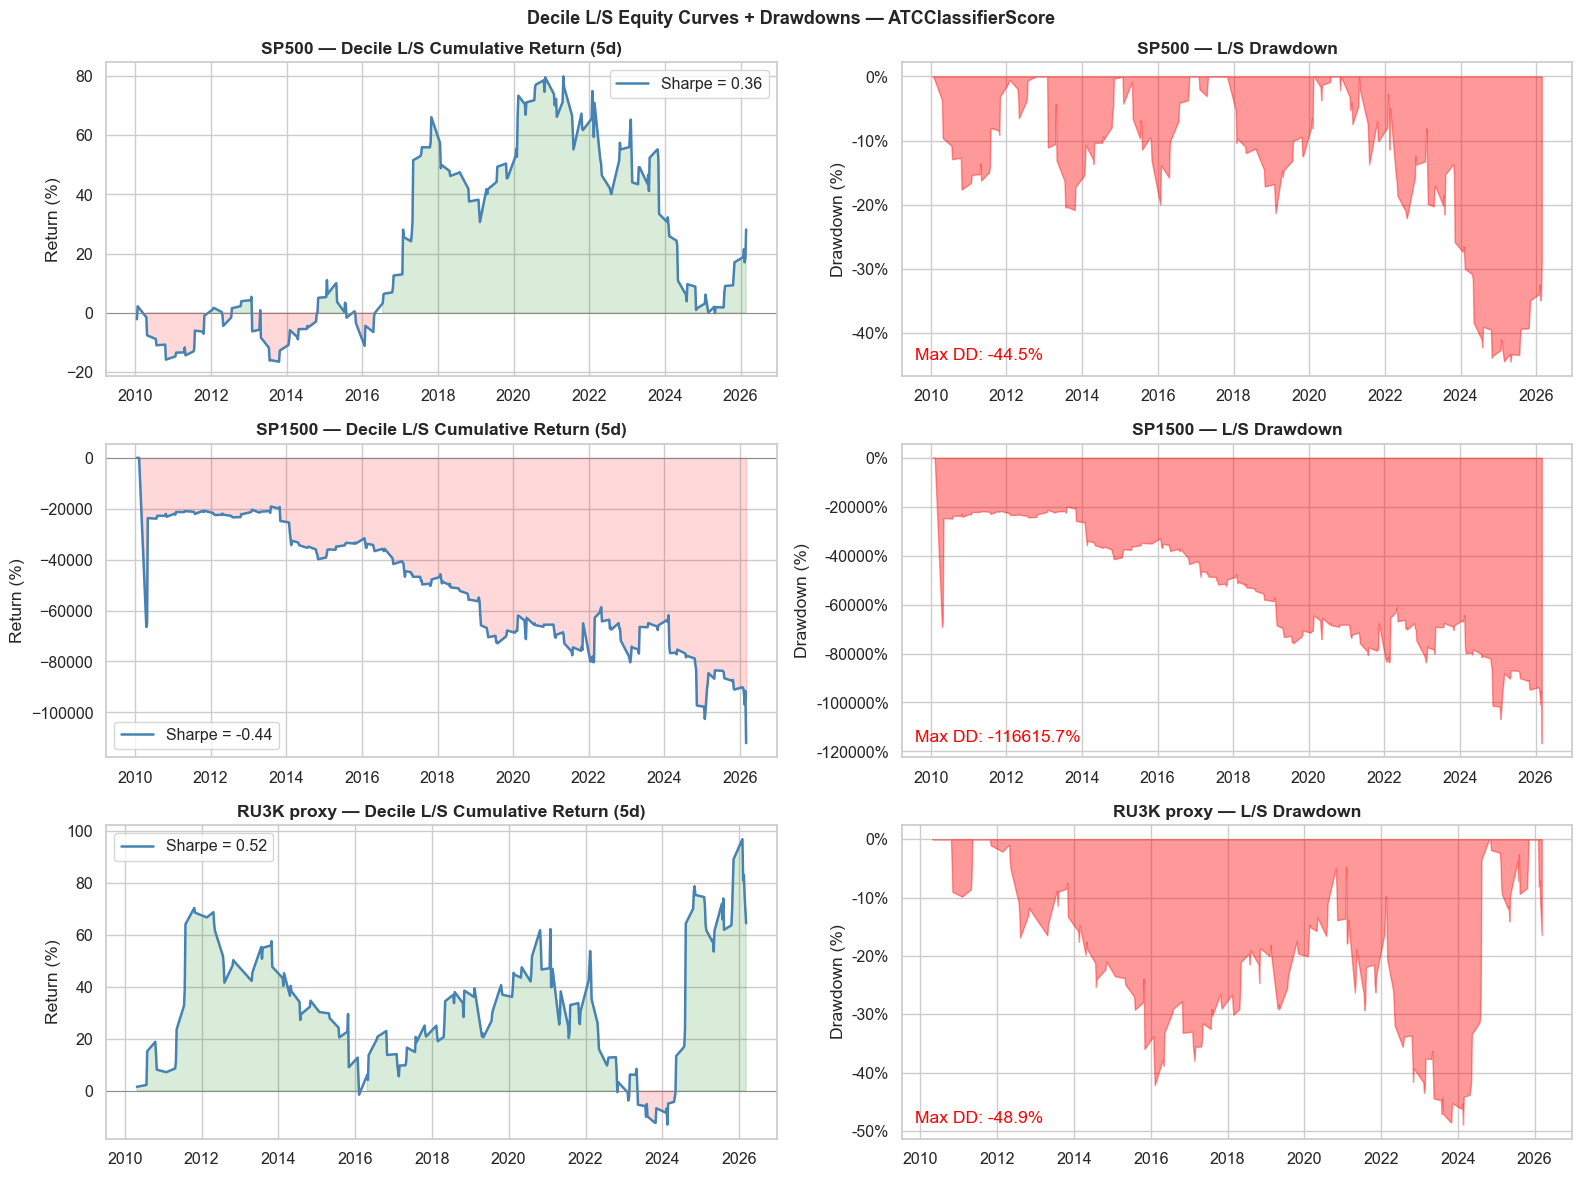

In [7]:
def drawdown_series(cum_ret: pd.Series) -> pd.Series:
    cumval = 1 + cum_ret
    peak   = cumval.expanding().max()
    return (cumval / peak) - 1


fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for row_idx, univ in enumerate(UNIVERSES):
    label = UNIV_LABELS[univ]

    # Decile L/S cumulative return
    _, cum_d, sh_d = quintile_backtest(
        feat_df, 'ATCClassifierScore', univ, horizon=5, n_quantiles=10
    )
    ax = axes[row_idx, 0]
    ax.plot(cum_d.index.to_timestamp(), cum_d['LS'] * 100, 'steelblue', lw=1.8,
            label=f'Sharpe = {sh_d["LS"]:.2f}')
    ax.fill_between(cum_d.index.to_timestamp(), 0, cum_d['LS']*100,
                    where=cum_d['LS']>0, alpha=0.15, color='green')
    ax.fill_between(cum_d.index.to_timestamp(), 0, cum_d['LS']*100,
                    where=cum_d['LS']<0, alpha=0.15, color='red')
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{label} — Decile L/S Cumulative Return (5d)', fontweight='bold')
    ax.set_ylabel('Return (%)')
    ax.legend()

    # Drawdown
    ax = axes[row_idx, 1]
    dd = drawdown_series(cum_d['LS'])
    ax.fill_between(dd.index.to_timestamp(), 0, dd*100, color='red', alpha=0.4)
    ax.set_title(f'{label} — L/S Drawdown', fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    max_dd = dd.min()
    ax.text(0.02, 0.05, f'Max DD: {max_dd:.1%}', transform=ax.transAxes, color='red')

fig.suptitle('Decile L/S Equity Curves + Drawdowns — ATCClassifierScore', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'decile_equity_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 IC Decay Curve

How fast does the signal decay? Plot mean IC across all horizons (1→20d). This justifies the choice of target horizon in the walk-forward model. The ATC classifier was trained on a 14-day window so we expect IC to peak somewhere around 5-10d and decay beyond 15d.

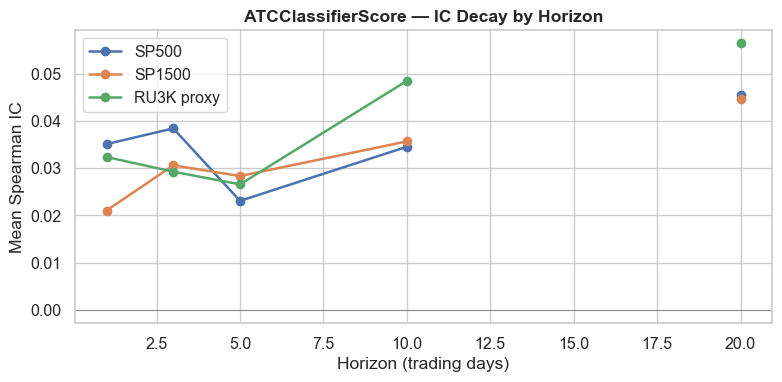

In [8]:
horizons_extended = [1, 3, 5, 10, 15, 20]

fig, ax = plt.subplots(figsize=(8, 4))

for univ in UNIVERSES:
    sub   = feat_df[feat_df[univ]].copy()
    label = UNIV_LABELS[univ]
    ics   = []
    for h in horizons_extended:
        col = f'fwd_{h}d'
        if col not in sub.columns:
            ics.append(np.nan)
            continue
        ics.append(spearman_ic(sub['ATCClassifierScore'], sub[col]))
    ax.plot(horizons_extended, ics, marker='o', label=label, lw=1.8)

ax.axhline(0, color='grey', lw=0.6)
ax.set_xlabel('Horizon (trading days)')
ax.set_ylabel('Mean Spearman IC')
ax.set_title('ATCClassifierScore — IC Decay by Horizon', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_decay_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Placebo Test (Red-Team Sanity Check)

Run the same quintile backtest using only the Fluff/Filler-derived signal.  
Expected result: L/S Sharpe ≈ 0, no consistent quintile ordering, no monotone IC.  
If this test fails (material positive Sharpe), there is a look-ahead bug.

=== PLACEBO TEST (Fluff/Filler signal only) ===
Expected: all Sharpes ≈ 0, no trend in cumulative L/S curve



SP500: Sharpe = 0.343  →  PASS ✓


SP1500: Sharpe = -0.396  →  PASS ✓


RU3K proxy: Sharpe = -0.207  →  PASS ✓


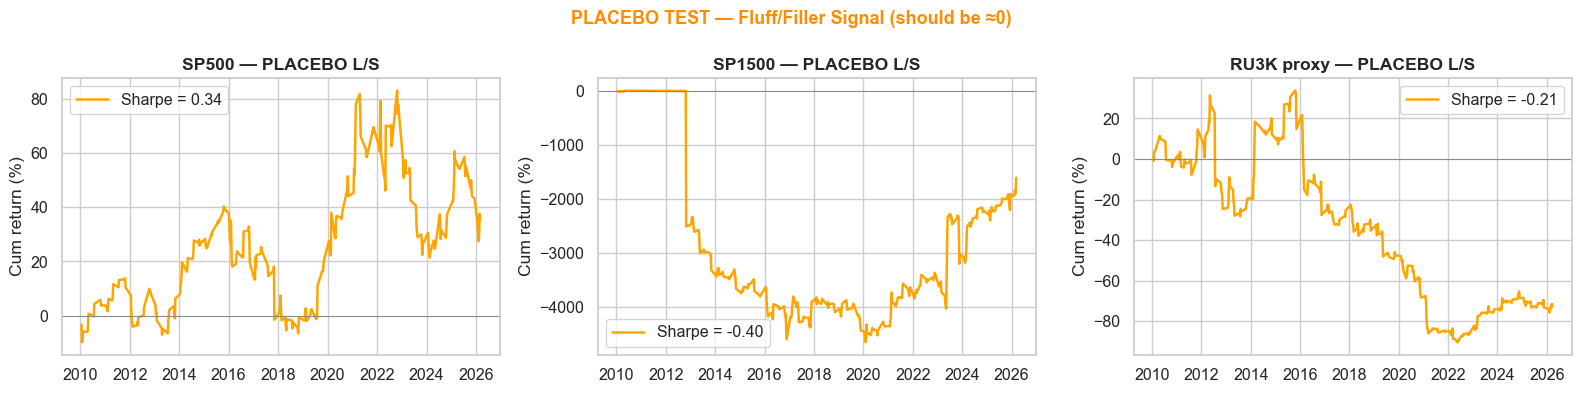

In [9]:
print('=== PLACEBO TEST (Fluff/Filler signal only) ===')
print('Expected: all Sharpes ≈ 0, no trend in cumulative L/S curve')
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, univ in zip(axes, UNIVERSES):
    label = UNIV_LABELS[univ]
    try:
        _, cum_p, sh_p = quintile_backtest(
            placebo_df, 'placebo_signal', univ, horizon=5
        )
        ax.plot(cum_p.index.to_timestamp(), cum_p['LS']*100, 'orange', lw=1.8,
                label=f'Sharpe = {sh_p["LS"]:.2f}')
        ax.axhline(0, color='grey', lw=0.6)
        ax.set_title(f'{label} — PLACEBO L/S', fontweight='bold')
        ax.set_ylabel('Cum return (%)')
        ax.legend()
        status = 'PASS ✓' if abs(sh_p['LS']) < 0.5 else 'FAIL ✗ — CHECK FOR LOOK-AHEAD!'
        print(f'{label}: Sharpe = {sh_p["LS"]:.3f}  →  {status}')
    except Exception as e:
        print(f'{label}: ERROR — {e}')

fig.suptitle('PLACEBO TEST — Fluff/Filler Signal (should be ≈0)', fontsize=13,
             fontweight='bold', color='darkorange')
plt.tight_layout()
plt.savefig(FIG_DIR / 'placebo_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.7 Speaker-Slice Comparison

The handout notes that speaker-specific slices may produce differentiated signals. Compare the IC of `ATCClassifierScore` across Total, CEO, CFO, and Analysts slices — are any slices more informative than the aggregate?

Speaker slice ATC columns found: ['atc_analysts', 'atc_answer', 'atc_ceo', 'atc_cfo', 'atc_presentation', 'atc_question', 'atc_total']

IC by speaker slice — SP500:
                        1d      3d      5d     10d     20d
ATCClassifierScore  0.0351  0.0384  0.0231  0.0345  0.0455
atc_analysts       -0.0027 -0.0006 -0.0068 -0.0141 -0.0061
atc_answer          0.0214  0.0305  0.0169  0.0117  0.0109
atc_ceo             0.0192  0.0159  0.0078  0.0070  0.0028
atc_cfo             0.0102  0.0174  0.0145  0.0102  0.0084
atc_presentation    0.0200  0.0273  0.0158  0.0072  0.0187
atc_question        0.0009 -0.0002 -0.0071 -0.0124 -0.0049
atc_total           0.0351  0.0384  0.0231  0.0345  0.0455


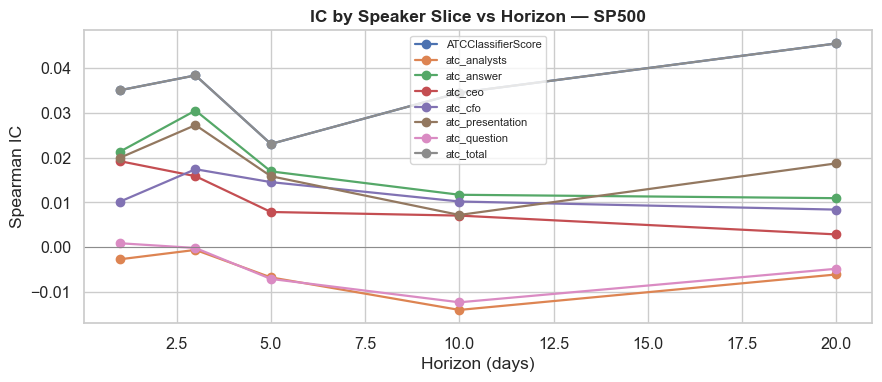

In [10]:
slice_atc_cols = [c for c in feat_df.columns if c.startswith('atc_')]
print('Speaker slice ATC columns found:', slice_atc_cols)

if slice_atc_cols:
    signal_cols = ['ATCClassifierScore'] + slice_atc_cols
    sub = feat_df[feat_df['in_sp500']].copy()

    slice_ic = {}
    for sc in signal_cols:
        slice_ic[sc] = [
            spearman_ic(sub[sc], sub[f'fwd_{h}d'])
            for h in HORIZONS
        ]

    slice_ic_df = pd.DataFrame(slice_ic, index=[f'{h}d' for h in HORIZONS]).T
    print('\nIC by speaker slice — SP500:')
    print(slice_ic_df.round(4).to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    for sc in signal_cols:
        ax.plot(HORIZONS, slice_ic[sc], marker='o', label=sc, lw=1.6)
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_xlabel('Horizon (days)')
    ax.set_ylabel('Spearman IC')
    ax.set_title('IC by Speaker Slice vs Horizon — SP500', fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'ic_by_speaker_slice.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Speaker slice columns not found — re-run notebook 03 first.')

## 4.8 IC by Year — Explicit Annual IC Table and Figure

Required deliverable: annual IC of ATCClassifierScore and EventScore variants vs forward returns, per universe.

In [11]:
import json, os
with open(DATA_DIR / 'col_registry.json') as f:
    col_reg = json.load(f)
EVENT_COLS = col_reg['event_cols']

feat_df['Year'] = pd.to_datetime(feat_df['entry_date']).dt.year

# ── Annual IC: ATCClassifierScore across all universes and horizons ────────────
ic_by_year_rows = []
for univ in UNIVERSES:
    sub = feat_df[feat_df[univ]].copy()
    for yr, g in sub.groupby('Year'):
        row = {'Universe': UNIV_LABELS[univ], 'Year': yr}
        for h in HORIZONS:
            row[f'IC_{h}d'] = spearman_ic(g['ATCClassifierScore'], g[f'fwd_{h}d'])
        ic_by_year_rows.append(row)

ic_yr_df = pd.DataFrame(ic_by_year_rows)
ic_yr_df.to_csv(DATA_DIR / 'ic_by_year.csv', index=False)
print('=== Annual IC: ATCClassifierScore ===')
print(ic_yr_df[ic_yr_df['Universe']=='SP1500'].set_index('Year').round(4).to_string())

# Heatmap: Year × Horizon, faceted by universe
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
for ax, univ_label in zip(axes, ['SP500', 'SP1500', 'RU3K proxy']):
    lbl = univ_label.split()[0]  # 'SP500', 'SP1500', 'RU3K'
    sub = ic_yr_df[ic_yr_df['Universe'] == ('RU3K' if 'RU3K' in univ_label else lbl)]
    if sub.empty:
        sub = ic_yr_df[ic_yr_df['Universe'] == lbl]
    heat = sub.set_index('Year')[[f'IC_{h}d' for h in HORIZONS]]
    sns.heatmap(heat.astype(float), ax=ax, cmap='RdYlGn', center=0,
                vmin=-0.12, vmax=0.12, annot=True, fmt='.3f',
                linewidths=0.4, cbar=(ax == axes[-1]))
    ax.set_title(f'{univ_label} — Annual IC', fontweight='bold')
    ax.set_xlabel('Horizon')

fig.suptitle('ATCClassifierScore: Annual Spearman IC by Universe × Horizon',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/ic_by_year.png  and  data/ic_by_year.csv')


=== Annual IC: ATCClassifierScore ===
     Universe   IC_1d   IC_3d   IC_5d  IC_10d  IC_20d
Year                                                 
2010   SP1500  0.0390  0.0470  0.0182 -0.0079 -0.0776
2011   SP1500  0.0137 -0.0158  0.0223 -0.0251  0.0121
2012   SP1500  0.0377  0.0275  0.0354  0.0513  0.0370
2013   SP1500  0.0424  0.0129  0.0222  0.0190 -0.0066
2014   SP1500  0.0536  0.0579  0.0615  0.0489  0.0902
2015   SP1500  0.0074  0.0088  0.0041  0.0355  0.0160
2016   SP1500  0.1030  0.0945  0.0849  0.0461  0.0723
2017   SP1500  0.0516  0.0713  0.0856  0.0943  0.1095
2018   SP1500  0.0069  0.0396  0.0442  0.0631  0.0503
2019   SP1500  0.0057  0.0648  0.0668  0.0748  0.0921
2020   SP1500  0.0150  0.0700  0.0758  0.1222  0.0032
2021   SP1500 -0.0113 -0.0204 -0.0357  0.0027  0.0952
2022   SP1500  0.0030 -0.0262 -0.0269 -0.0172  0.0179
2023   SP1500 -0.0225  0.0076  0.0166  0.0274  0.0666
2024   SP1500  0.0160  0.0159  0.0261  0.0399  0.0321
2025   SP1500  0.0255  0.0391  0.0025 -0.005

Saved → figures/ic_by_year.png  and  data/ic_by_year.csv


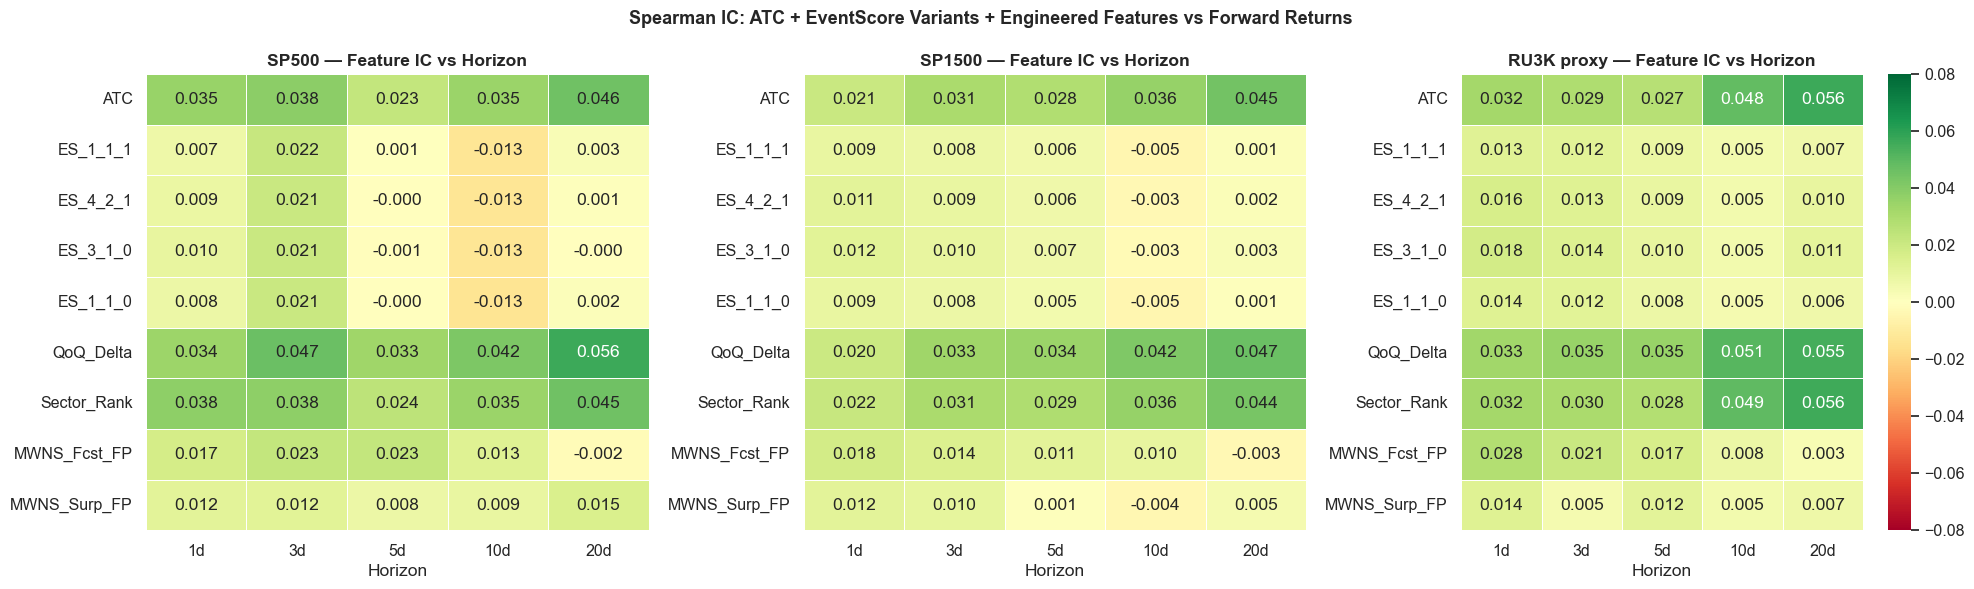

In [12]:
# ── EventScore IC heatmap: all 4 score variants + ATC + key engineered features ─
SIGNAL_SET = (['ATCClassifierScore']
              + [c for c in feat_df.columns if c.startswith('EventsScore_')]
              + ['qoq_delta', 'sector_pct_rank',
                 'mwns_Forecast_FinancialPerformance',
                 'mwns_Surprise_FinancialPerformance'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, univ in zip(axes, UNIVERSES):
    sub   = feat_df[feat_df[univ]].copy()
    label = UNIV_LABELS[univ]
    ic_mat = {}
    for sig in SIGNAL_SET:
        if sig not in sub.columns:
            continue
        ic_mat[sig] = [spearman_ic(sub[sig], sub[f'fwd_{h}d']) for h in HORIZONS]

    ic_heat = pd.DataFrame(ic_mat, index=[f'{h}d' for h in HORIZONS]).T
    # Shorten row labels for readability
    ic_heat.index = [r.replace('EventsScore_','ES_').replace('ATCClassifierScore','ATC')
                      .replace('mwns_Forecast_FinancialPerformance','MWNS_Fcst_FP')
                      .replace('mwns_Surprise_FinancialPerformance','MWNS_Surp_FP')
                      .replace('sector_pct_rank','Sector_Rank')
                      .replace('qoq_delta','QoQ_Delta')
                     for r in ic_heat.index]

    sns.heatmap(ic_heat.astype(float), ax=ax, cmap='RdYlGn', center=0,
                vmin=-0.08, vmax=0.08, annot=True, fmt='.3f',
                linewidths=0.4, cbar=(ax == axes[-1]))
    ax.set_title(f'{label} — Feature IC vs Horizon', fontweight='bold')
    ax.set_xlabel('Horizon')

fig.suptitle('Spearman IC: ATC + EventScore Variants + Engineered Features vs Forward Returns',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_ic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# ── Long-only / Short-only / Long-Short decomposition ─────────────────────────
def ls_decomp(df, signal_col, univ_col, horizon=5, n_quantiles=5, tc_bps=5):
    """Return long-only, short-only, and L/S Sharpe + CAGR separately."""
    tc_cost = tc_bps / 10_000
    sub     = df[df[univ_col]].copy()
    ret_col = f'fwd_{horizon}d'
    sub     = sub.dropna(subset=[signal_col, ret_col])

    def safe_qcut(s):
        if len(s) < n_quantiles:
            return pd.Series(np.nan, index=s.index)
        try:
            return pd.qcut(s.rank(method='first'), n_quantiles,
                           labels=range(1, n_quantiles + 1), duplicates='drop')
        except ValueError:
            return pd.Series(np.nan, index=s.index)

    sub['quintile'] = sub.groupby('entry_date')[signal_col].transform(safe_qcut)
    sub = sub.dropna(subset=['quintile'])
    sub['quintile']  = sub['quintile'].astype(int)
    sub['period']    = sub['entry_date'].dt.to_period('W')

    rets = sub.groupby(['period', 'quintile'])[ret_col].mean().unstack('quintile')
    top = n_quantiles
    if top not in rets.columns or 1 not in rets.columns:
        return {}
    rets.columns = [f'Q{i}' for i in rets.columns]
    long_r  = rets[f'Q{top}'] - tc_cost
    short_r = -rets['Q1']     - tc_cost
    ls_r    = rets[f'Q{top}'] - rets['Q1'] - 2 * tc_cost

    ppy = 252 / horizon
    def ann_sh(s): return s.dropna().mean() / (s.dropna().std() + 1e-9) * np.sqrt(ppy)
    def ann_ret(s): return (1 + s.dropna()).prod() ** (ppy / max(len(s.dropna()), 1)) - 1

    return {
        'Long Sharpe'  : round(ann_sh(long_r),  3),
        'Short Sharpe' : round(ann_sh(short_r), 3),
        'L/S Sharpe'   : round(ann_sh(ls_r),    3),
        'Long CAGR'    : f'{ann_ret(long_r):.1%}',
        'Short CAGR'   : f'{ann_ret(short_r):.1%}',
        'L/S CAGR'     : f'{ann_ret(ls_r):.1%}',
        'N events'     : len(sub),
    }

rows = []
for univ in UNIVERSES:
    for h in [5, 10, 20]:
        res = ls_decomp(feat_df, 'ATCClassifierScore', univ, horizon=h)
        if res:
            rows.append({'Universe': UNIV_LABELS[univ], 'Horizon': f'{h}d', **res})

decomp_df = pd.DataFrame(rows)
print('=== LONG / SHORT / L-S DECOMPOSITION (ATCClassifierScore) ===')
print(decomp_df.to_string(index=False))
decomp_df.to_csv(DATA_DIR / 'ls_decomposition.csv', index=False)
print('\nSaved → data/ls_decomposition.csv')


=== LONG / SHORT / L-S DECOMPOSITION (ATCClassifierScore) ===
  Universe Horizon  Long Sharpe  Short Sharpe  L/S Sharpe Long CAGR Short CAGR L/S CAGR  N events
     SP500      5d        0.439        -0.756      -0.292      8.1%     -20.7%   -12.9%      9621
     SP500     10d        0.250        -0.275      -0.042      3.1%     -11.5%    -5.9%      9555
     SP500     20d        0.524        -0.016       0.513     12.0%      -4.8%    11.8%      9216
    SP1500      5d        0.269        -0.394      -0.393      3.7%       nan%     nan%     21791
    SP1500     10d        0.483        -0.285       0.068      9.5%     -18.7%    -7.4%     21600
    SP1500     20d        0.447        -0.359      -0.029      9.5%       nan%     nan%     20847
RU3K proxy      5d        0.429         0.094       0.435     85.6%      -4.4%    86.0%      9567
RU3K proxy     10d        0.339         0.172       0.353     52.5%      -0.4%    59.3%      9430
RU3K proxy     20d        0.694         0.147       0.73

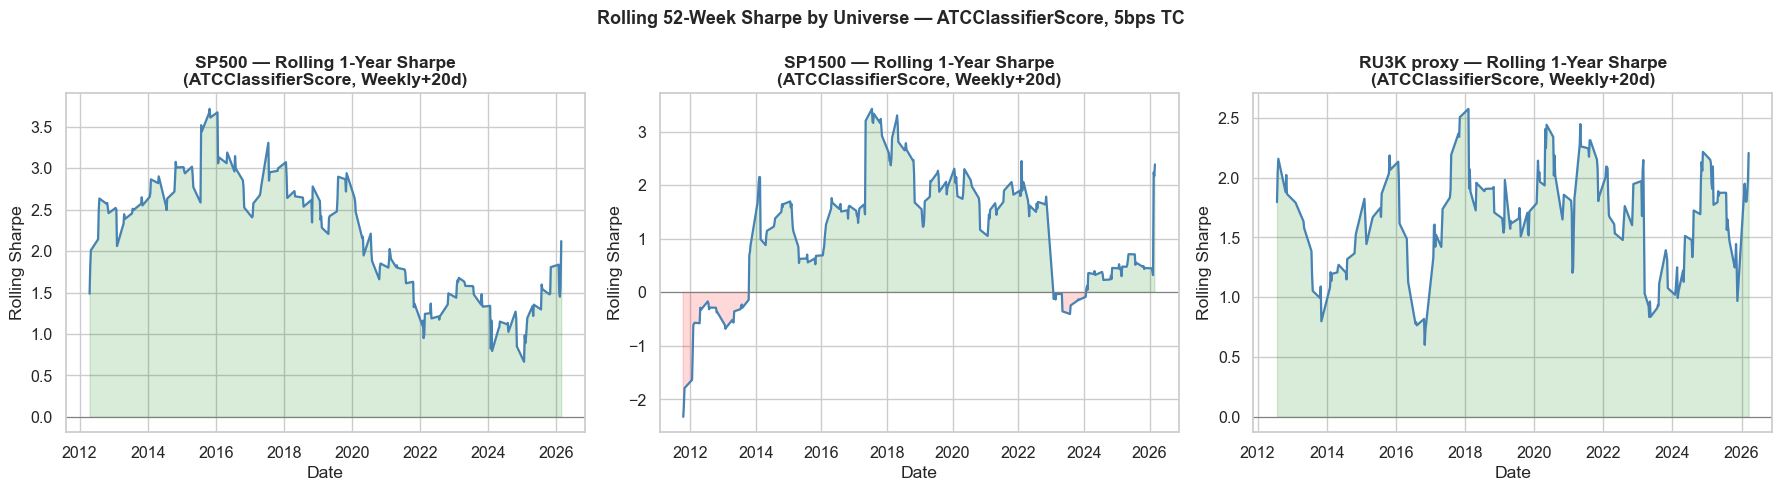

In [14]:
# ── Rolling 1-year Sharpe — standalone figure ─────────────────────────────────
def rolling_sharpe_series(df, signal_col, univ_col, horizon=20, freq='W', window=52):
    ret_col = f'fwd_{horizon}d'
    sub = df[df[univ_col]].dropna(subset=[signal_col, ret_col]).copy()
    sub['period'] = sub['entry_date'].dt.to_period(freq)
    rows, pl, ps = [], set(), set()
    for period, grp in sub.groupby('period'):
        if len(grp) < 20: continue
        n = max(int(len(grp)*0.1), 1)
        ranked = grp.sort_values(signal_col)
        longs  = set(ranked.tail(n)['BESTTICKER'])
        shorts = set(ranked.head(n)['BESTTICKER'])
        lr  = grp[grp['BESTTICKER'].isin(longs)][ret_col].mean()
        sr  = grp[grp['BESTTICKER'].isin(shorts)][ret_col].mean()
        turn = (1-len(longs&pl)/max(len(longs|pl),1)+1-len(shorts&ps)/max(len(shorts|ps),1))/2 if pl else 1.0
        rows.append({'period': period, 'net_ls': (lr-sr) - 2*turn*(5/10000)})
        pl, ps = longs, shorts
    if not rows: return pd.Series(dtype=float)
    r = pd.DataFrame(rows).set_index('period')['net_ls']
    ppy = {'W': 52, 'M': 12}[freq]
    return r.rolling(window, min_periods=window//2).apply(
        lambda x: x.mean()/(x.std()+1e-9)*np.sqrt(ppy)
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, univ in zip(axes, UNIVERSES):
    lbl = UNIV_LABELS[univ]
    rs  = rolling_sharpe_series(feat_df, 'ATCClassifierScore', univ, horizon=20, freq='W')
    if not rs.empty:
        ax.plot(rs.index.to_timestamp(), rs.values, 'steelblue', lw=1.6)
        ax.fill_between(rs.index.to_timestamp(), 0, rs.values,
                        where=rs.values > 0, alpha=0.15, color='green')
        ax.fill_between(rs.index.to_timestamp(), 0, rs.values,
                        where=rs.values < 0, alpha=0.15, color='red')
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_title(f'{lbl} — Rolling 1-Year Sharpe\n(ATCClassifierScore, Weekly+20d)', fontweight='bold')
    ax.set_ylabel('Rolling Sharpe')
    ax.set_xlabel('Date')

fig.suptitle('Rolling 52-Week Sharpe by Universe — ATCClassifierScore, 5bps TC',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rolling_sharpe_by_universe.png', dpi=150, bbox_inches='tight')
plt.show()
